# Zepto Sales Data Analysis Project

Project Overview

Welcome, aspiring Data Analysts! This project is designed to give you hands-on experience with real-world, industry-grade sales data from Zepto, a popular quick-commerce platform. You will apply your Python skills, particularly using the Pandas and Matplotlib libraries, to explore, clean, analyze, and visualize a dataset containing over 200,000 sales records and a product catalog.

This project will reinforce your understanding of data manipulation, data cleaning techniques, and fundamental data visualization, preparing you for more complex analytical tasks.

Dataset Description
You will be working with two CSV files:

zepto_sales.csv: Contains individual sales transactions.
zepto_products.csv: Contains details about the products sold.bold



```
# This is formatted as code
```





In [ ]:
# import libararias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load the dataset
df_sales = pd.read_csv(r"/content/sample_data/zepto_sales.csv")
df_product  = pd.read_csv(r"/content/sample_data/zepto_products.csv")

In [ ]:
# display basic information for sale data

print("---sales data info---")
df_sales.info()
print("---sales data discription---")
print(df_sales.describe())
print("---sales data shape---")
print(df_sales.shape)
print("---sales data head---")
print(df_sales.head())
print("---sales data tail---")
print(df_sales.tail())

# display basic information for product data

print("---product data info---")
df_product.info()
print("---product data discription---")
print(df_product.describe())
print("---product data shape---")
print(df_product.shape)
print("---product data head---")
print(df_product.head())
print("---product data tail---")
print(df_product.tail())

---sales data info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220220 entries, 0 to 220219
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            220220 non-null  int64  
 1   order_date          220220 non-null  object 
 2   product_id          220220 non-null  int64  
 3   quantity            220220 non-null  int64  
 4   city                219118 non-null  object 
 5   delivery_status     219118 non-null  object 
 6   customer_id         220220 non-null  int64  
 7   delivery_time_mins  215817 non-null  float64
 8   total_amount        220220 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 15.1+ MB
---sales data discription---
            order_id     product_id       quantity    customer_id  \
count  220220.000000  220220.000000  220220.000000  220220.000000   
mean   152325.652429     119.214218       1.548633   60016.100023   
std     30172.20034

In [ ]:
# check for null values in data sales

print("---null valuse in data sales (before cleaning)---")
print(df_sales.isnull().sum())

# handel null values in 'city' and 'delivery_status' by dropping rows
# Calculate mean AFTER dropping rows, to ensure it's based on cleaned data
df_sales.dropna(subset=['city', 'delivery_status'], inplace= True)
print("nulls values after dropping rows in city/delivery_status:")
print(df_sales[["city", "delivery_status"]].isnull().sum())

#  handel null values in 'delivery_time_mins' by filling with the mean
mean_delivery_time = df_sales["delivery_time_mins"].mean()
df_sales["delivery_time_mins"].fillna(mean_delivery_time, inplace=True)
print("---nulls values  after filling mean in delivery_time_mins:")
print(df_sales["delivery_time_mins"].isnull().sum())

# ckeck for duplicate records
print("---duplicate records in data sales:")
print(f"number of duplicate records: {df_sales.duplicated().sum()}")

# remove duplicate records
df_sales.drop_duplicates(inplace = True)
print(f"number of raw after removing duplicates: {df_sales.shape[0]}")

# convert  'order_date' to datetime object
df_sales["order_date"] = pd.to_datetime(df_sales["order_date"])
print("---data types aftr cleaning and conversion:")
df_sales.info()


---null valuse in data sales (before cleaning)---
order_id                 0
order_date               0
product_id               0
quantity                 0
city                  1102
delivery_status       1102
customer_id              0
delivery_time_mins    4403
total_amount             0
dtype: int64
nulls values after dropping rows in city/delivery_status:
city               0
delivery_status    0
dtype: int64
---nulls values  after filling mean in delivery_time_mins:
0
---duplicate records in data sales:


/tmp/ipykernel_1020/642958334.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_sales["delivery_time_mins"].fillna(mean_delivery_time, inplace=True)


number of duplicate records: 216
number of raw after removing duplicates: 217806
---data types aftr cleaning and conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 217806 entries, 0 to 220219
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            217806 non-null  int64         
 1   order_date          217806 non-null  datetime64[ns]
 2   product_id          217806 non-null  int64         
 3   quantity            217806 non-null  int64         
 4   city                217806 non-null  object        
 5   delivery_status     217806 non-null  object        
 6   customer_id         217806 non-null  int64         
 7   delivery_time_mins  217806 non-null  float64       
 8   total_amount        217806 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 16.6+ MB


In [ ]:
# find min, max, and average total amount

min_amount = df_sales["total_amount"].min()
max_amount = df_sales["total_amount"].max()
avg_amount = df_sales["total_amount"].mean()
print(f"min total amount :{min_amount:.2f}")
print(f"max total amount :{max_amount:.2f}")
print(f"avg total amount :{avg_amount:.2f}")

# top 5 product  by total sales amount
top_product = df_sales.groupby("product_id")["total_amount"].sum().nlargest(5)
print("---top 5 product by total sales amount---")
print(top_product)

# marge with the product dtails to get product name
top_product_datails = top_product.reset_index().merge(df_product , on="product_id")
print("----top 5 product by sales amount (with names)----")
print(top_product_datails,[["product_id", "category", "total_amount"]])

# total  sales by city
sales_by_city = df_sales.groupby("city")["total_amount"].sum().sort_values(ascending=False)
print("---total sales by city---")
print(sales_by_city)

# avrage delivery time by city
avg_delivery_time_by_city = df_sales.groupby("city")["delivery_time_mins"].mean().sort_values()
print("---avrage delivery time by city (minits)---")
print(avg_delivery_time_by_city)

# sales trend over time (e.g., monthly sales)
df_sales["month"] = df_sales["order_date"].dt.to_period("M")
monthly_sales =df_sales.groupby("month")["total_amount"].sum()
print("---monthly sales trend---")
print(monthly_sales)

# sales by product category
sales_by_category = df_sales.merge(df_product, on="product_id")
sales_by_category = sales_by_category.groupby("category")["total_amount"].sum().sort_values(ascending=False)
print("---total sales by product category---")
print(sales_by_category)

min total amount :23.25
max total amount :2656.85
avg total amount :302.32
---top 5 product by total sales amount---
product_id
134    11658720.91
112     7908234.46
135     6171994.29
129     4796676.99
131     4716913.11
Name: total_amount, dtype: float64
----top 5 product by sales amount (with names)----
   product_id  total_amount   product_name              category  base_price
0         134   11658720.91       Handwash         Personal Care      390.59
1         112    7908234.46    Paneer 200g          Dairy & Eggs      226.87
2         135    6171994.29     Toothpaste         Personal Care      182.49
3         129    4796676.99  Detergent 1kg  Household Essentials      531.37
4         131    4716913.11   Toilet Paper  Household Essentials      513.21 [['product_id', 'category', 'total_amount']]
---total sales by city---
city
Mumbai       23063075.50
Bangalore    16385777.49
Delhi         9937151.01
Hyderabad     5305224.53
Pune          4559465.47
Kolkata       2671042.99
Che

/tmp/ipykernel_1020/122889757.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_by_city.index, y=sales_by_city.values, palette='magma', ax=axes[0,1])
/tmp/ipykernel_1020/122889757.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='delivery_status', data=df_sales, palette ='deep', ax=axes[1, 2])
/tmp/ipykernel_1020/122889757.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y='delivery_time_mins', data= df_sales, palette= 'coolwarm', ax=axes[2, 0])
/tmp/ipykernel_1020/122889757.py:55: FutureWarning: 

Passing `p

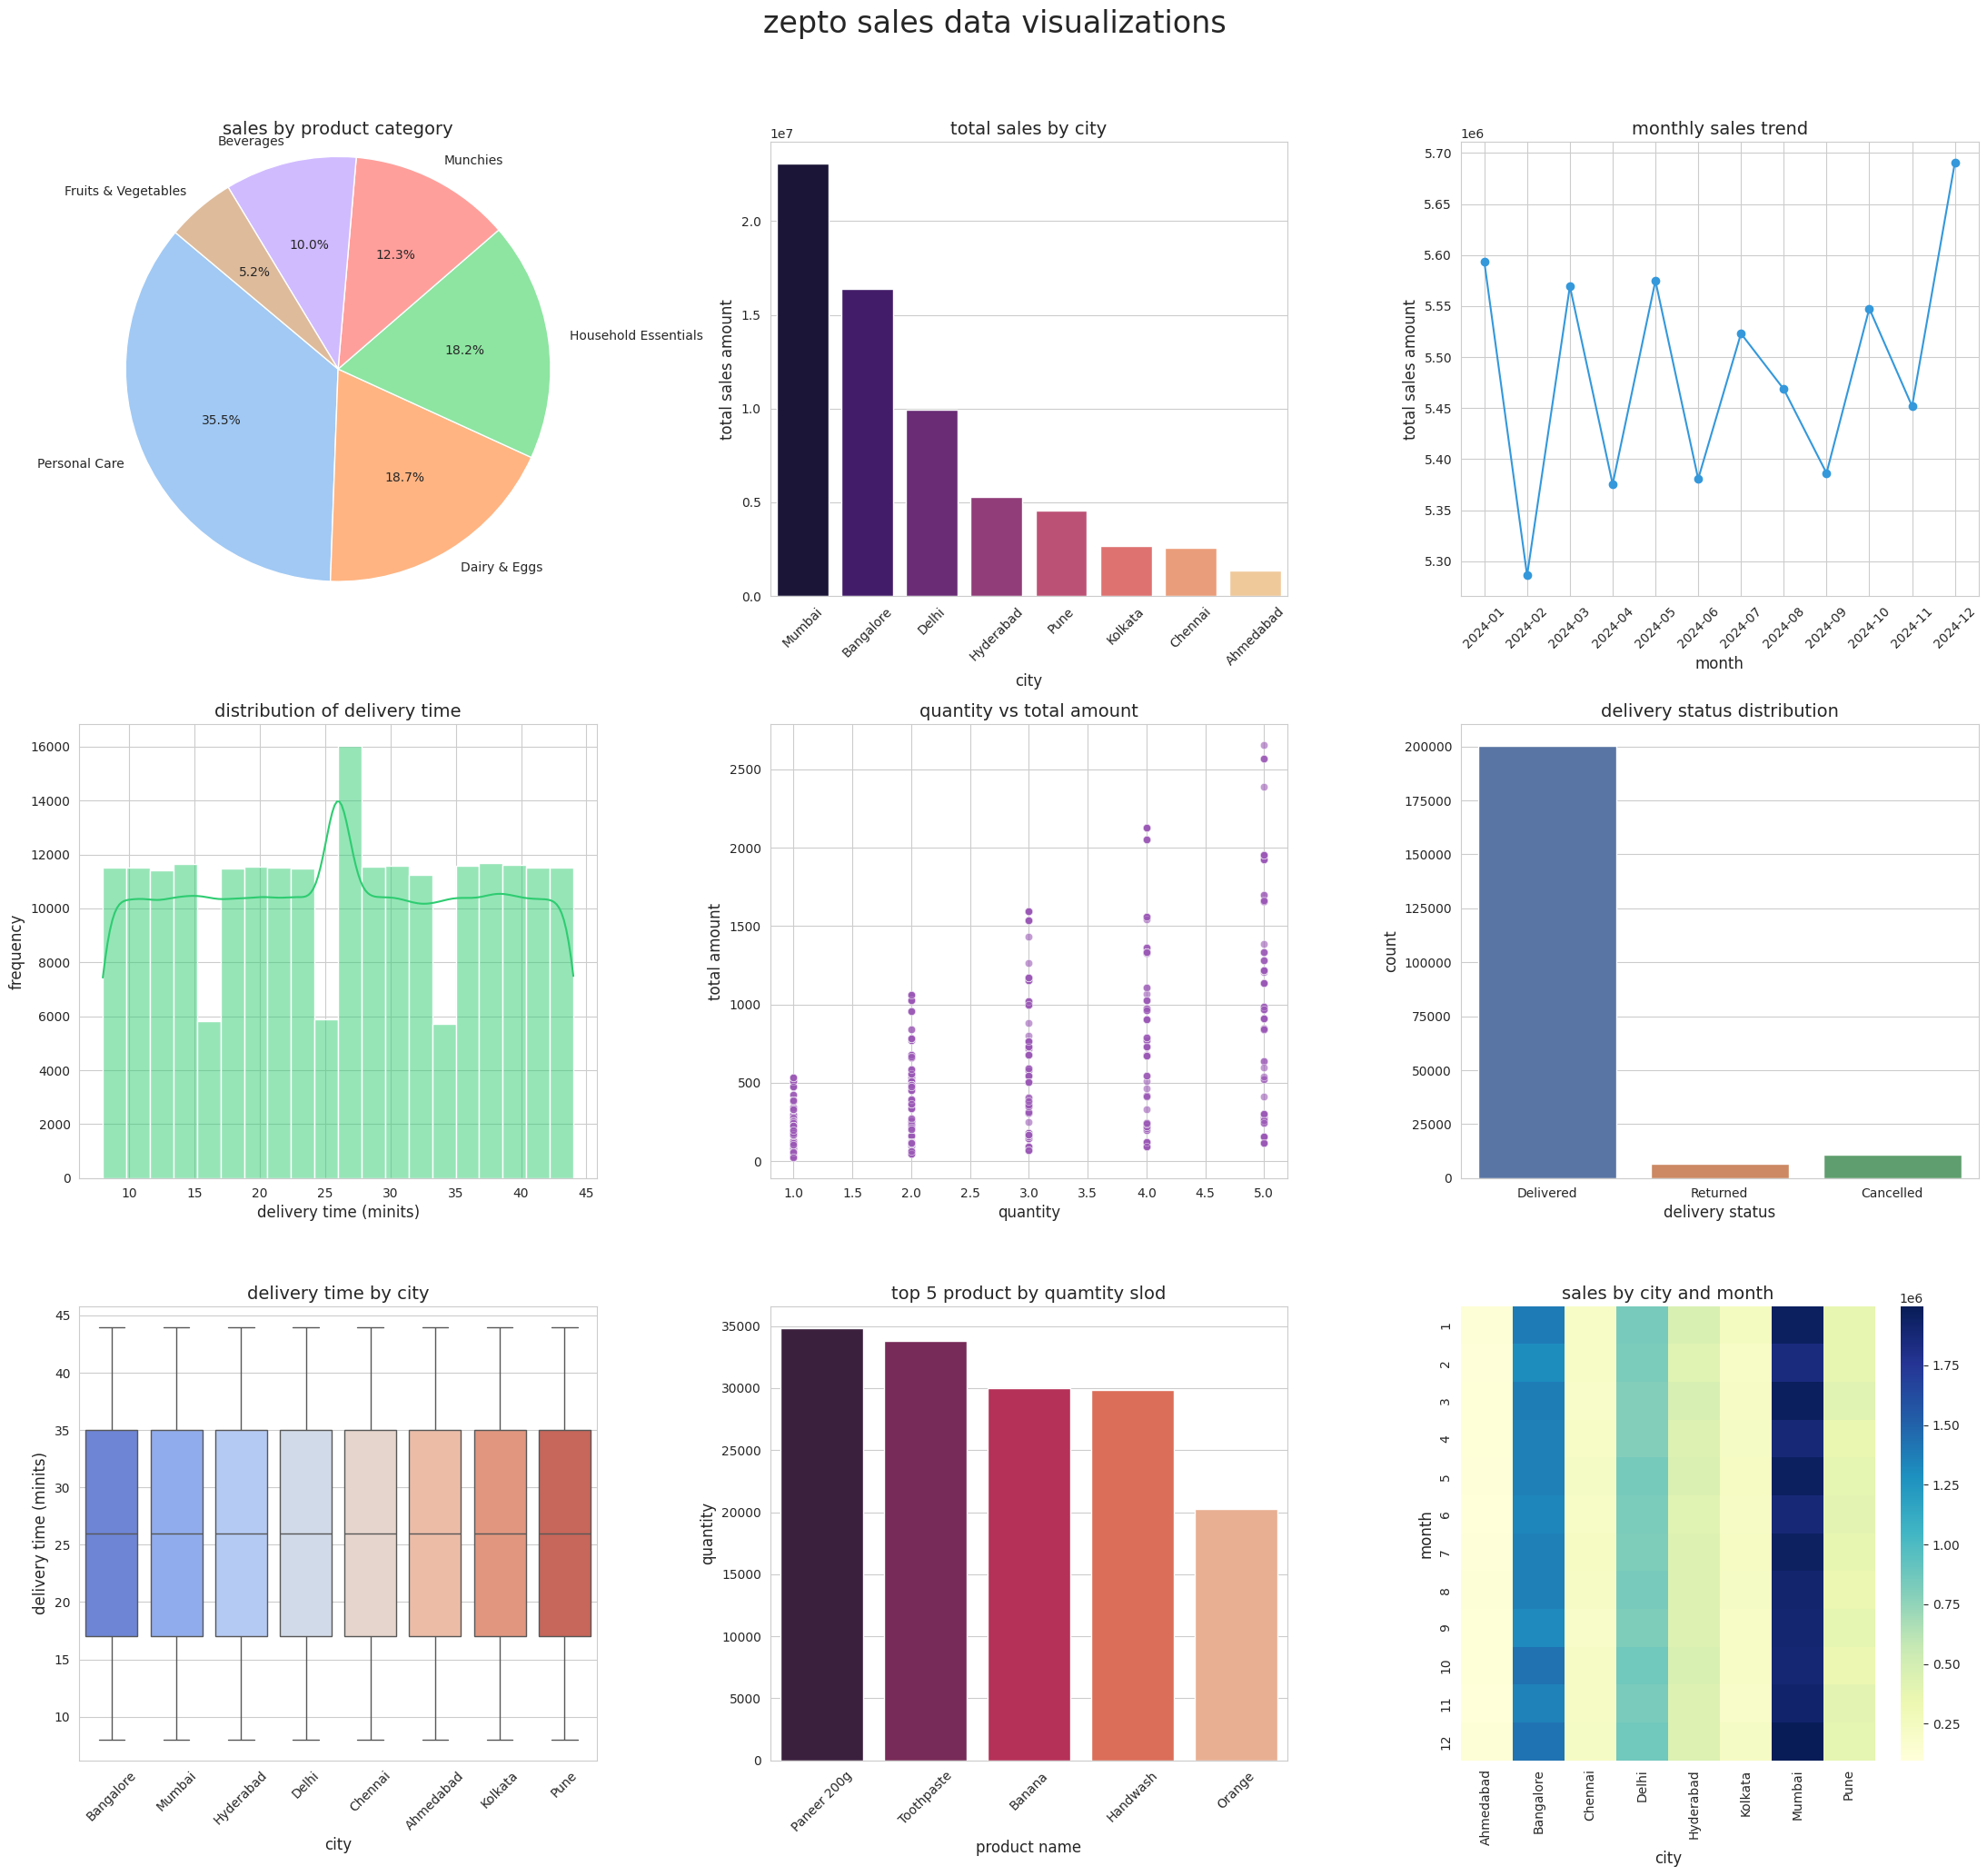

In [ ]:
sns.set_style("whitegrid")

# craete a 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize =(22, 20))
fig.suptitle("zepto sales data visualizations", fontsize=24, y=1.03)

# plot 1: monthly sales trend (line chart)
axes[0, 2].plot(monthly_sales.index.astype(str), monthly_sales.values, marker ='o',color='#3498DB')
axes[0, 2].set_title('monthly sales trend', fontsize= 14)
axes[0, 2].set_xlabel('month', fontsize= 12)
axes[0, 2].set_ylabel('total sales amount', fontsize= 12)
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(True)

# plot 2: total sales by city (bar chart)
sns.barplot(x=sales_by_city.index, y=sales_by_city.values, palette='magma', ax=axes[0,1])
axes[0, 1].set_title('total sales by city', fontsize = 14)
axes[0, 1].set_xlabel('city', fontsize =12)
axes[0, 1].set_ylabel('total sales amount', fontsize= 12)
axes[0, 1].tick_params(axis= 'x', rotation=45)

# plot 3: sales by product category (pie chart)
axes[0, 0].pie(sales_by_category, labels= sales_by_category.index, autopct='%1.1f%%', startangle = 140, colors=sns.color_palette('pastel'))
axes[0, 0].set_title('sales by product category', fontsize=14)
axes[0, 0].axis('equal')

# plot 4: Distribution of  delivery times (histogram)
sns.histplot(df_sales['delivery_time_mins'], bins=20, kde= True, color ='#2ECC71', ax=axes[1, 0])
axes[1, 0].set_title('distribution of delivery time', fontsize=14)
axes[1, 0].set_xlabel('delivery time (minits)', fontsize =12)
axes[1, 0].set_ylabel('frequency', fontsize= 12)

# plot 5: quantity vs total amount (scatter plot)
sns.scatterplot(x='quantity', y= 'total_amount', data= df_sales.sample(n=5000), alpha=0.6, color= '#9B59B6', ax=axes[1, 1])
axes[1, 1].set_title('quantity vs total amount',fontsize = 14)
axes[1, 1].set_xlabel('quantity', fontsize =12)
axes[1, 1].set_ylabel('total amount', fontsize =12)

# plot 6: delivery status distribution (count plot)
sns.countplot(x='delivery_status', data=df_sales, palette ='deep', ax=axes[1, 2])
axes[1, 2].set_title('delivery status distribution', fontsize= 14)
axes[1, 2].set_xlabel('delivery status', fontsize= 12)
axes[1, 2].set_ylabel('count', fontsize= 12)

# plot 7: delivery time by city (box plot)
sns.boxplot(x='city', y='delivery_time_mins', data= df_sales, palette= 'coolwarm', ax=axes[2, 0])
axes[2, 0].set_title('delivery time by city', fontsize= 14)
axes[2, 0].set_xlabel('city', fontsize = 12)
axes[2, 0].set_ylabel('delivery time (minits)', fontsize= 12)
axes[2, 0].tick_params(axis='x', rotation= 45)

# plot 8: top 5 product by  quantity sold (bar plot)
top_product_quantity = df_sales.groupby('product_id')['quantity'].sum().nlargest(5).reset_index()
top_product_quantity = top_product_quantity.merge(df_product, on='product_id')
sns.barplot(x='product_name',y= 'quantity', data= top_product_quantity, palette= 'rocket', ax=axes[2, 1])
axes[2, 1].set_title('top 5 product by quamtity slod', fontsize =14)
axes[2, 1].set_xlabel('product name', fontsize= 12)
axes[2, 1].set_ylabel('quantity', fontsize= 12)
axes[2, 1].tick_params(axis= 'x', rotation = 45)

# plot 9: sales by city and month (heatmap)
sales_city_month = df_sales.groupby([df_sales['order_date'].dt.month, 'city'])["total_amount"].sum().unstack(fill_value= 0)
sns.heatmap(sales_city_month, cmap='YlGnBu', ax=axes[2, 2])
axes[2, 2].set_title('sales by city and month', fontsize = 14)
axes[2, 2].set_xlabel('city', fontsize= 12)
axes[2, 2].set_ylabel('month', fontsize= 12)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

